# v3 - bottom and plume release, W sign test, no particles lost

Four runs: two release regions (shelf bottom cell, Amazon plume mouth) x two vertical
conventions (`+W` as stored, `-W`). 28 days, dt 20 min, output 6 h.

## Why `-W` is the correct field, not a fudge

**1. The files say so.** GLORYS' own CF metadata:

```
vovecrtz:  standard_name = upward_sea_water_velocity
depthw:    positive = down
```

The velocity is positive *upward*; the vertical coordinate is positive *downward*. They point in
opposite directions.

**2. Parcels integrates along the depth axis.** `AdvectionRK4_3D` does
`particle_ddepth += w*dt`, so it treats W as $dz/dt$ where $z$ is Parcels' depth coordinate -
here `depthw`, increasing downward. Measured in v1: $dz/dt = +1.08\,W$. So supplying the
upward velocity makes particles move opposite to the true vertical motion.

**3. Negation is the coordinate transformation, and it preserves non-divergence.** With
$z_{down} = -z_{up}$ and $W_{parcels} = -\omega$,

$$\frac{\partial W_{parcels}}{\partial z_{down}} = -\frac{\partial \omega}{\partial z_{down}}
= \frac{\partial \omega}{\partial z_{up}}
\;\Rightarrow\;
\frac{\partial u}{\partial x}+\frac{\partial v}{\partial y}+\frac{\partial W_{parcels}}{\partial z_{down}} = 0 .$$

So the triple $(u, v, -\omega)$ is divergence-free **in Parcels' own coordinate system**. The
discrete version is the same relation the data satisfies: reconstructing
$\omega_k = \omega_{k+1} - \nabla\!\cdot\!F_k/A$ from U and V reproduces GLORYS' `vovecrtz` with
correlation 1.000000 and rms difference 3e-10. Had the stored field been positive-down, that
reconstruction would have come out anti-correlated.

**4. It behaves.** v2, same seeds: `+W` drove 168 of 200 particles into the seafloor (median
4.6 m *below* the bed); `-W` left 6. An independent tracker (`JackMacklarvae.m`, which shares
the same convention) gave 180 and 62.

This is a convention mismatch, not a Parcels bug - `gridindexingtype="nemo"` fixes NEMO's index
staggering but leaves the sign to the user. It is easy to miss because most Parcels work is 2-D,
where W never enters.

## No vertical boundary condition is imposed

Nothing is reflected, clamped, deleted or kept alive. Passive particles have no inertia and
nothing to bounce off, so a bounce rule would be a numerical patch dressed up as physics.

None is needed. The kinematic condition at an impermeable boundary is `w = 0`, and the data
satisfies it **exactly** - at the free surface (`k = 0`) and at the bottom face of the deepest
wet cell (`k = mbathy`), in all 425,361 wet columns:

```
                 |w| at k=0     |w| at k=mbathy
poisson_b         2.0e-17          0.000e+00
fix_w             0.000e+00        0.000e+00
raw GLORYS        3.7e-06          0.000e+00
```

A particle approaching a face where `w -> 0` decelerates and cannot cross it in finite time.
So a crossing, if one happens, is numerical (RK4 truncation) and is **measured** below rather
than patched away.

### The floor is `gdepw_0[mbathy]`, not the true seabed

This is where the earlier version of this notebook went wrong. The zero-`w` value is stored at
index `k = mbathy`, and Parcels labels that index with depth `gdepw_0[mbathy]`. The physical
seabed `H = gdepw_0[mbathy-1] + e3t_ps` - the bottom of the partial cell - lies *above* it:

| | mean gap | max gap | columns > 1 m |
|---|---|---|---|
| whole domain | 118.10 m | 422.50 m | 345,936 of 425,361 (81.3%) |
| shelf 20-100 m | 2.52 m | 12.63 m | |

Between `H` and `gdepw_0[mbathy]` the interpolated `w` is nonzero, so the field's own no-flux
face is the deeper one, and that gap is open water as far as the velocity field is concerned.
Reflecting off `H` therefore erected a wall inside water the field considers open - which is
what generated the 309,925 "bed reflections" that the previous version reported. The wall
created the collisions it then corrected.

Both depths are recorded per particle below, so `below floor` (a genuine violation) and
`below H` (expected, the partial-cell gap) can be read apart.


In [1]:
SMOKE = False                      # True -> 3-day validation run

n_per_region       = 200
run_time_days      = 3 if SMOKE else 28
time_step_minutes  = 20
out_put_step_hours = 6

ref_date, offset = "1993-01-01", 1
rdm_seed = 110987

Hgr, Zgr = "Hgr_cmesh.nc", "Zgr_cmesh2.nc"
FIELDS   = dict(U="U_1993-01b.nc", V="V_1993-01b.nc", W="W_1993-01b.nc")

SHELF_H  = (20.0, 100.0)                                   # bottom release: shelf depths
SHELF_BOX = dict(lon=(-52, -46), lat=(-1.5, 4.5))
PLUME_LINE = dict(lon=(-49.916, -49.083), lat=(1.166, -0.0833), z=(0.0, 10.0))

out_root    = "tracks_v3_smoke" if SMOKE else "tracks_v3"
FORCE_RERUN = False

In [2]:
import os, sys, shutil, contextlib
import numpy as np
import xarray as xr
from datetime import timedelta
from scipy.spatial import cKDTree
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from parcels import FieldSet, Field, ParticleSet, JITParticle, Variable, AdvectionRK4_3D, StatusCode

@contextlib.contextmanager
def quiet():
    sys.stdout.flush()
    saved, devnull = os.dup(1), os.open(os.devnull, os.O_WRONLY)
    try:
        os.dup2(devnull, 1); yield
    finally:
        os.dup2(saved, 1); os.close(devnull); os.close(saved)

start_time = np.datetime64(ref_date) + np.timedelta64(offset, "D")
nout = int(run_time_days * 24 / out_put_step_hours) + 1
print(f"{start_time} + {run_time_days} d   dt={time_step_minutes} min   {nout} outputs")

1993-01-02 + 28 d   dt=20 min   113 outputs


## 1. Grid, true seabed, and the two release sets

In [3]:
zgr = xr.open_dataset(Zgr).squeeze()
hgr = xr.open_dataset(Hgr).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")
gdept_0 = zgr.gdept_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values.astype("f8"), zgr.nav_lat.values.astype("f8")
glamf, gphif = hgr.glamf.values.astype("f8"), hgr.gphif.values.astype("f8")
nz, ny, nx = len(gdepw_0), *mbathy.shape

kb   = np.clip(mbathy - 1, 0, nz - 1)
thick = np.where(mbathy > 0, e3t_ps, 0.0)
H     = gdepw_0[kb] + thick                 # TRUE seabed (bottom of the partial cell)
Gnom  = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, nz - 1)], 0.0)
#       ^ depth Parcels assigns the zero-w face at k=mbathy: the field's own floor
zbot  = gdepw_0[kb] + 0.5 * thick           # middle of the deepest wet cell

wj, wi = np.where(mbathy > 0)
tree   = cKDTree(np.column_stack([lon2d[wj, wi], lat2d[wj, wi]]))
Hw     = H[wj, wi]
def seabed_at(lo, la):
    f = np.column_stack([np.ravel(lo), np.ravel(la)]); ok = np.isfinite(f).all(1)
    o = np.full(len(f), np.nan)
    if ok.any(): o[ok] = Hw[tree.query(f[ok])[1]]
    return o.reshape(np.shape(lo))

rng = np.random.default_rng(rdm_seed)

# --- bottom: middle of the deepest wet cell, shelf columns -----------------------------
shelf = ((mbathy > 0) & (H > SHELF_H[0]) & (H < SHELF_H[1])
         & (lon2d > SHELF_BOX["lon"][0]) & (lon2d < SHELF_BOX["lon"][1])
         & (lat2d > SHELF_BOX["lat"][0]) & (lat2d < SHELF_BOX["lat"][1]))
jj, ii = np.where(shelf)
sel = rng.choice(len(jj), size=n_per_region, replace=len(jj) < n_per_region)
bj, bi = jj[sel], ii[sel]
REL = {"bottom": (lon2d[bj, bi], lat2d[bj, bi], zbot[bj, bi])}

# --- plume: the release line, 0-10 m, draws below the bed discarded and redrawn --------
def seed_line(n, zlo, zhi):
    lo, la, zz = np.empty(n), np.empty(n), np.empty(n)
    got = drawn = 0
    while got < n:
        m = max(n - got, 16)
        t = rng.uniform(0, 1, m)
        cl = PLUME_LINE["lon"][0] + t * (PLUME_LINE["lon"][1] - PLUME_LINE["lon"][0])
        ca = PLUME_LINE["lat"][0] + t * (PLUME_LINE["lat"][1] - PLUME_LINE["lat"][0])
        cz = rng.uniform(zlo, zhi, m)
        ok = cz < seabed_at(cl, ca)
        k = min(int(ok.sum()), n - got)
        if k:
            lo[got:got+k], la[got:got+k], zz[got:got+k] = cl[ok][:k], ca[ok][:k], cz[ok][:k]
            got += k
        drawn += m
    print(f"  plume: discarded {drawn - got} of {drawn} draws below the seabed")
    return lo, la, zz

REL["plume"] = seed_line(n_per_region, *PLUME_LINE["z"])

for r, (lo, la, z) in REL.items():
    bed = seabed_at(lo, la)
    print(f"  {r:<7} n={len(lo)}  z {z.min():7.2f}-{z.max():7.2f} m   "
          f"bed {bed.min():7.2f}-{bed.max():7.2f} m   all inside: {bool(np.all(z < bed))}")

  plume: discarded 40 of 240 draws below the seabed
  bottom  n=200  z   20.49-  91.87 m   bed   21.00-  98.98 m   all inside: True
  plume   n=200  z    0.02-   9.80 m   bed    7.00-  33.50 m   all inside: True


## 2. Bathymetry as a Field, so the kernel can reflect at the real bed

In [4]:
# Parcels' `cgrid_tracer` interpolator returns data[yi+1, xi+1] - exactly the T-point of the
# cell the particle is in, piecewise constant. So the arrays go in unshifted and the kernel
# reads the containing column's own value. (A bilinear field instead blends neighbouring
# columns and, on the shelf staircase, reports a seabed belonging to no column at all.)
# Both fields are DIAGNOSTIC ONLY - no kernel uses them to move a particle.
print(f"bathy (true seabed H) : {np.nanmin(H[H>0]):8.1f} - {H.max():8.1f} m")
print(f"floor (gdepw_0[mbathy]): {np.nanmin(Gnom[Gnom>0]):8.1f} - {Gnom.max():8.1f} m")
gap = (Gnom - H)[mbathy > 0]
print(f"partial-cell gap        : mean {gap.mean():.2f} m, max {gap.max():.2f} m, "
      f"{100*(gap>1).mean():.1f}% of wet columns > 1 m")


bathy (true seabed H) :      7.0 -   5958.4 m
floor (gdepw_0[mbathy]):      7.2 -   5500.0 m
partial-cell gap        : mean 118.10 m, max 422.50 m, 81.3% of wet columns > 1 m


## 3. Kernels

In [5]:
def AdvectionRK4_3D_negW(particle, fieldset, time):  # pragma: no cover
    '''RK4 with dz/dt = -W, i.e. W stored positive upward on a positive-down depth axis.'''
    (u1, v1, w1) = fieldset.UVW[particle]
    lon1 = particle.lon + u1 * 0.5 * particle.dt
    lat1 = particle.lat + v1 * 0.5 * particle.dt
    dep1 = particle.depth - w1 * 0.5 * particle.dt
    (u2, v2, w2) = fieldset.UVW[time + 0.5 * particle.dt, dep1, lat1, lon1, particle]
    lon2 = particle.lon + u2 * 0.5 * particle.dt
    lat2 = particle.lat + v2 * 0.5 * particle.dt
    dep2 = particle.depth - w2 * 0.5 * particle.dt
    (u3, v3, w3) = fieldset.UVW[time + 0.5 * particle.dt, dep2, lat2, lon2, particle]
    lon3 = particle.lon + u3 * particle.dt
    lat3 = particle.lat + v3 * particle.dt
    dep3 = particle.depth - w3 * particle.dt
    (u4, v4, w4) = fieldset.UVW[time + particle.dt, dep3, lat3, lon3, particle]
    particle_dlon += (u1 + 2 * u2 + 2 * u3 + u4) / 6 * particle.dt  # noqa
    particle_dlat += (v1 + 2 * v2 + 2 * v3 + v4) / 6 * particle.dt  # noqa
    particle_ddepth -= (w1 + 2 * w2 + 2 * w3 + w4) / 6 * particle.dt  # noqa


def Diagnose(particle, fieldset, time):  # pragma: no cover
    '''Measurement only. Records how far outside the water column a particle gets, and never
    touches its position - so what follows is the field's behaviour, not a kernel's.'''
    hb = fieldset.bathy[time, 0.0, particle.lat, particle.lon]   # true seabed H
    hf = fieldset.floor[time, 0.0, particle.lat, particle.lon]   # field's zero-w face
    if particle.depth - hb > particle.below_H:
        particle.below_H = particle.depth - hb
    if particle.depth - hf > particle.below_F:
        particle.below_F = particle.depth - hf
    if -particle.depth > particle.above_S:
        particle.above_S = -particle.depth


def CheckError(particle, fieldset, time):  # pragma: no cover
    '''A particle that genuinely leaves the domain is deleted and counted as a loss. It is not
    kept alive in place: that would freeze it and hide the failure behind a full track count.'''
    if particle.state >= 50:
        particle.delete()


class TrackParticle(JITParticle):
    reg     = Variable("reg", initial=0, dtype=np.int32, to_write="once")
    below_H = Variable("below_H", initial=0.0, dtype=np.float32)
    below_F = Variable("below_F", initial=0.0, dtype=np.float32)
    above_S = Variable("above_S", initial=0.0, dtype=np.float32)


## 4. Run

In [6]:
REGIONS = list(REL)
start_lon = np.concatenate([REL[r][0] for r in REGIONS])
start_lat = np.concatenate([REL[r][1] for r in REGIONS])
start_dep = np.concatenate([REL[r][2] for r in REGIONS])
start_reg = np.concatenate([np.full(n_per_region, k) for k in range(len(REGIONS))])
npart = len(start_lon)

def build_fieldset():
    fn = {v: {"data": FIELDS[v], "lon": Hgr, "lat": Hgr, "depth": FIELDS["W"]}
          for v in ("U", "V", "W")}
    fs = FieldSet.from_netcdf(
        fn, {"U": "vozocrtx", "V": "vomecrty", "W": "vovecrtz"},
        {v: {"lon": "glamf", "lat": "gphif", "depth": "depthw", "time": "time_counter"}
         for v in ("U", "V", "W")},
        interp_method={v: "cgrid_velocity" for v in ("U", "V", "W")},
        deferred_load=True, allow_time_extrapolation=False, gridindexingtype="nemo")
    for nm, arr in (("bathy", H), ("floor", Gnom)):
        fs.add_field(Field(nm, arr, lon=glamf, lat=gphif,
                           mesh="spherical", interp_method="cgrid_tracer"))
    return fs

def run(tag, kernel):
    out = os.path.join(out_root, f"{tag}.zarr")
    if os.path.exists(out) and not FORCE_RERUN:
        print(f"  reusing {out}"); return out
    if os.path.exists(out): shutil.rmtree(out)
    os.makedirs(out_root, exist_ok=True)
    ps = ParticleSet(build_fieldset(), TrackParticle, lon=start_lon, lat=start_lat,
                     depth=start_dep, time=np.datetime64(start_time), reg=start_reg)
    pf = ps.ParticleFile(name=out, outputdt=timedelta(hours=out_put_step_hours),
                         chunks=(npart, nout + 2))
    with quiet():
        ps.execute([kernel, Diagnose, CheckError],
                   runtime=timedelta(days=run_time_days),
                   dt=timedelta(minutes=time_step_minutes), output_file=pf)
    return out

paths = {}
for tag, kern in [("posW", AdvectionRK4_3D), ("negW", AdvectionRK4_3D_negW)]:
    print(f"===== {tag} =====")
    paths[tag] = run(tag, kern)
print("done")

===== posW =====


INFO: Output files are stored in tracks_v3/posW.zarr.


  0%|          | 0/2419200.0 [00:00<?, ?it/s]

  0%|          | 1200.0/2419200.0 [00:02<1:33:37, 430.46it/s]

  1%|          | 21600.0/2419200.0 [00:03<04:35, 8703.39it/s]

...

 98%|█████████▊| 2376000.0/2419200.0 [02:32<00:03, 13124.46it/s]

 99%|█████████▉| 2397600.0/2419200.0 [02:33<00:01, 14956.27it/s]

100%|██████████| 2419200.0/2419200.0 [02:34<00:00, 16627.11it/s]

100%|██████████| 2419200.0/2419200.0 [02:34<00:00, 15627.07it/s]


done


In [7]:
TRK = {}
for tag, pth in paths.items():
    d = xr.open_zarr(pth).compute()
    lat = d.lat.values; keep = np.isfinite(lat).any(axis=0)
    lo, la = d.lon.values[:, keep], lat[:, keep]
    TRK[tag] = dict(lon=lo, lat=la, z=np.where(np.isfinite(la), d.z.values[:, keep], np.nan),
                    reg=d.reg.values, bed=seabed_at(lo, la),
                    bH=d.below_H.values, bF=d.below_F.values, aS=d.above_S.values,
                    t=np.arange(keep.sum()) * out_put_step_hours / 24.0)

# `below floor` is the only genuine violation: gdepw_0[mbathy] is the face where the data has
# w = 0 exactly. `below H` is expected to be positive - to the field, the partial-cell gap
# between the true seabed and that face is open water.
print(f"{'run':<6}{'released':>10}{'tracked':>9}{'lost':>6}"
      f"{'below floor n':>15}{'max m':>9}"
      f"{'below H n':>11}{'max m':>9}"
      f"{'above surf n':>14}{'max m':>9}")
for tag, v in TRK.items():
    mx = lambda a: np.nanmax(a, axis=1)
    bF, bH, aS = mx(v["bF"]), mx(v["bH"]), mx(v["aS"])
    n = np.isfinite(v["lat"]).sum(axis=1)
    print(f"{tag:<6}{npart:>10}{int((n == v['lat'].shape[1]).sum()):>9}"
          f"{int((n < v['lat'].shape[1]).sum()):>6}"
          f"{int((bF > 1e-6).sum()):>15}{np.nanmax(bF):>9.3f}"
          f"{int((bH > 1e-6).sum()):>11}{np.nanmax(bH):>9.3f}"
          f"{int((aS > 1e-6).sum()):>14}{np.nanmax(aS):>9.3f}")


run     released  tracked  lost  below floor n    max m  below H n    max m  above surf n    max m
posW         400      400     0              4    0.055        247   11.624             0    0.000
negW         400      400     0              0    0.000        163    8.535             0    0.000


## 5. Maps of the tracks

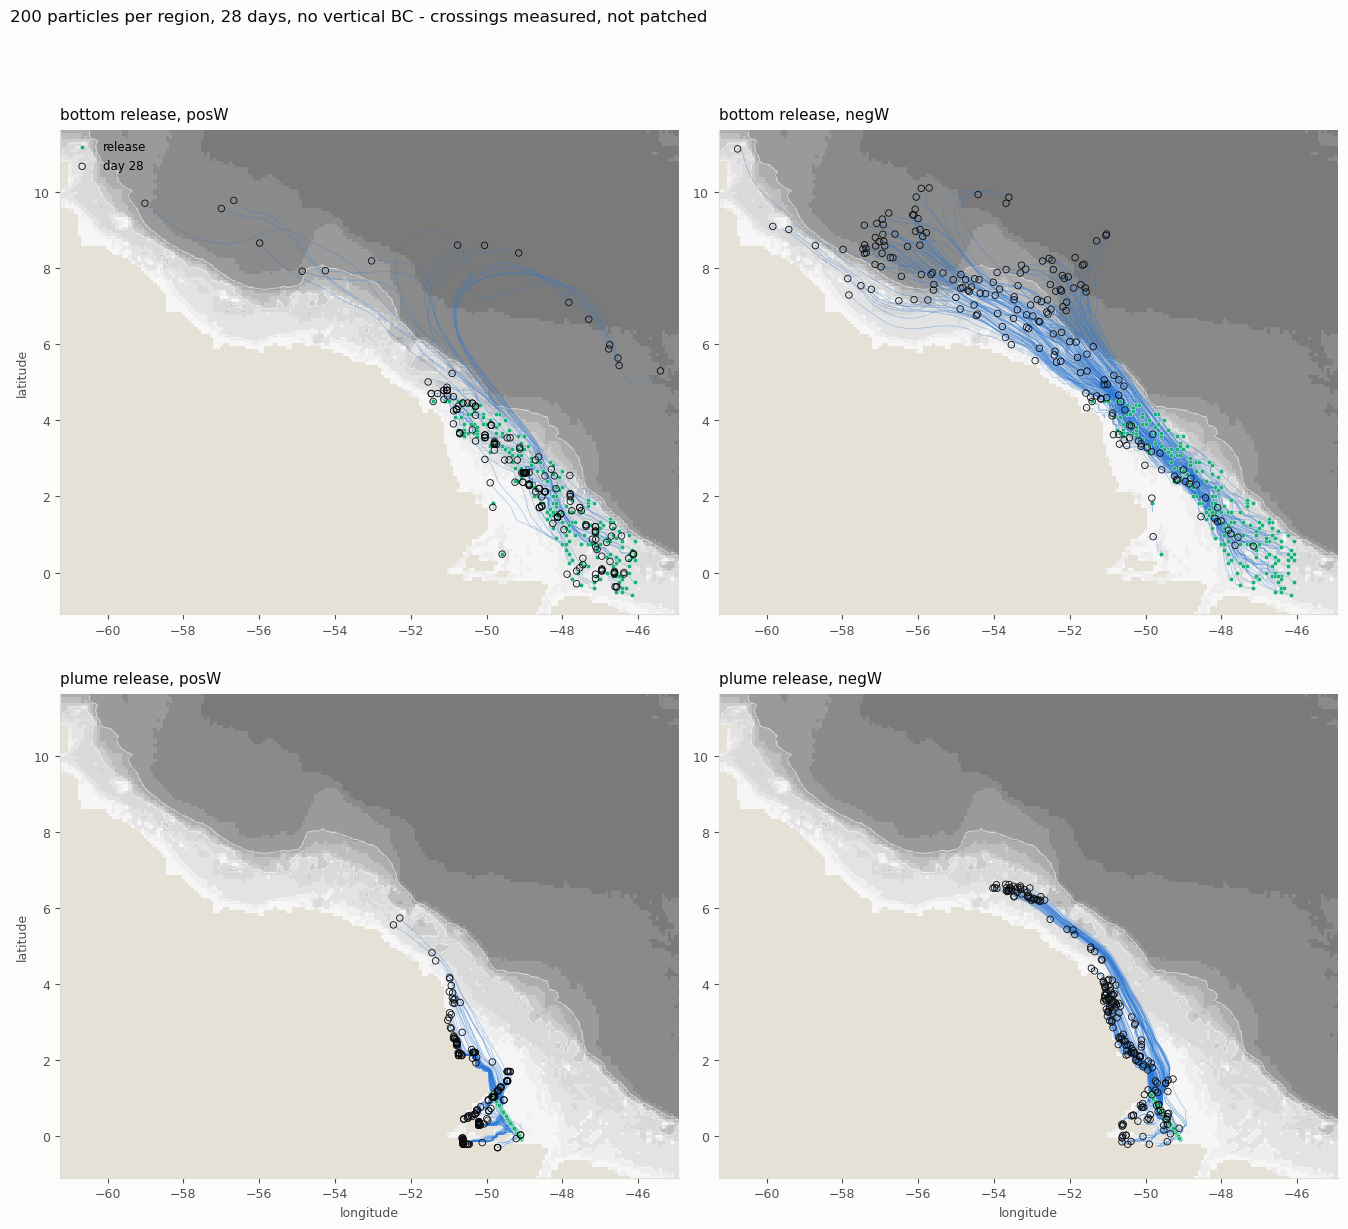

In [8]:
SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

allon = np.concatenate([v["lon"].ravel() for v in TRK.values()])
allat = np.concatenate([v["lat"].ravel() for v in TRK.values()])
x0, x1 = np.nanmin(allon) - 0.5, np.nanmax(allon) + 0.5
y0, y1 = np.nanmin(allat) - 0.5, np.nanmax(allat) + 0.5
m = (lon2d >= x0) & (lon2d <= x1) & (lat2d >= y0) & (lat2d <= y1)
gj, gi = np.where(m); Js, Is = slice(gj.min(), gj.max()+1), slice(gi.min(), gi.max()+1)
LEV = [0, 10, 20, 50, 100, 200, 500, 1000, 2000, 4000, 6000]
bc = ListedColormap(mpl.colormaps["Greys"](np.linspace(0.08, 0.6, len(LEV)-1)))
bc.set_bad("#e6e1d6"); bn = BoundaryNorm(LEV, bc.N)
BATH = np.where(mbathy[Js, Is] > 0, H[Js, Is], np.nan)

fig, axs = plt.subplots(2, 2, figsize=(13.5, 12.4))
for row, reg in enumerate(REGIONS):
    for col, tag in enumerate(["posW", "negW"]):
        ax = axs[row, col]; v = TRK[tag]; sel = v["reg"] == row
        ax.set_facecolor("#e6e1d6")
        pc = ax.pcolormesh(lon2d[Js, Is], lat2d[Js, Is], BATH, cmap=bc, norm=bn,
                           shading="auto", zorder=0)
        ax.contour(lon2d[Js, Is], lat2d[Js, Is], np.nan_to_num(BATH), levels=[20, 100, 1000],
                   colors="#ffffff", linewidths=0.5, alpha=0.7, zorder=1)
        ax.plot(v["lon"][sel].T, v["lat"][sel].T, lw=0.5, color="#2a78d6", alpha=0.4, zorder=2)
        ax.scatter(v["lon"][sel, 0], v["lat"][sel, 0], s=10, color="#1baf7a",
                   edgecolor="white", linewidth=0.25, zorder=4, label="release")
        nb_ = np.isfinite(v["lat"][sel]).sum(axis=1)
        lastq = np.where(nb_ > 0, nb_ - 1, 0); rq = np.arange(int(sel.sum()))
        ax.scatter(v["lon"][sel][rq, lastq], v["lat"][sel][rq, lastq], s=22,
                   facecolor="none", edgecolor="#0b0b0b", linewidth=0.6, zorder=5,
                   label=f"day {run_time_days}")
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1)
        ax.set_aspect(1 / np.cos(np.deg2rad(np.mean([y0, y1]))))
        ax.set_title(f"{reg} release, {tag}", loc="left", fontsize=11, pad=8)
        if row == 1: ax.set_xlabel("longitude")
        if col == 0: ax.set_ylabel("latitude")
        if row == 0 and col == 0: ax.legend(frameon=False, fontsize=8.5, loc="upper left")
        for s in ("top", "right"): ax.spines[s].set_visible(False)
fig.suptitle(f"{n_per_region} particles per region, {run_time_days} days, "
             "no vertical BC - crossings measured, not patched",
             x=0.006, ha="left", fontsize=12, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig(f"v3_tracks{'_smoke' if SMOKE else ''}.png", dpi=170, facecolor=SURF)
plt.show()

## 6. Are any particles static?


In [9]:
R = 6371.0
def hav_km(lo1, la1, lo2, la2):
    """Haversine in float64 - stable at short range, unlike the arccos form on float32 data."""
    q = np.pi / 180
    a1, a2 = np.asarray(la1, "f8") * q, np.asarray(la2, "f8") * q
    dlo = (np.asarray(lo2, "f8") - np.asarray(lo1, "f8")) * q
    h = np.sin((a2 - a1) / 2) ** 2 + np.cos(a1) * np.cos(a2) * np.sin(dlo / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(np.clip(h, 0, 1)))

SLOW = {}
for tag, v in TRK.items():
    lo, la = v["lon"], v["lat"]
    step = hav_km(lo[:, :-1], la[:, :-1], lo[:, 1:], la[:, 1:])
    path = np.nansum(step, axis=1)
    n = np.isfinite(la).sum(axis=1); last = np.where(n > 0, n - 1, 0); r = np.arange(len(n))
    net = hav_km(lo[:, 0], la[:, 0], lo[r, last], la[r, last])
    SLOW[tag] = (path, net, step)
    print(f"=== {tag} ===")
    for k, reg in enumerate(REGIONS):
        s = v["reg"] == k
        print(f"  {reg:<7} path: min {path[s].min():8.2f}  median {np.median(path[s]):8.1f} km"
              f"   |  net: min {net[s].min():8.2f} km"
              f"   |  n(path<5 km) = {int((path[s] < 5).sum())}")
    print()

=== posW ===
  bottom  path: min     4.62  median     62.7 km   |  net: min     0.96 km   |  n(path<5 km) = 10
  plume   path: min     8.25  median    146.7 km   |  net: min     2.78 km   |  n(path<5 km) = 0

=== negW ===
  bottom  path: min     5.83  median    914.2 km   |  net: min     0.96 km   |  n(path<5 km) = 0
  plume   path: min    37.56  median    332.1 km   |  net: min    11.60 km   |  n(path<5 km) = 0



In [10]:
# the five least mobile in each run, with the cell geometry that explains them
kk3 = np.arange(nz - 1)[:, None, None]
wet3 = (kk3 + 1) <= mbathy
ue = np.zeros_like(wet3); ue[:, :, :-1] = wet3[:, :, :-1] & wet3[:, :, 1:]
uw = np.zeros_like(wet3); uw[:, :,  1:] = wet3[:, :, :-1] & wet3[:, :, 1:]
vn = np.zeros_like(wet3); vn[:, :-1, :] = wet3[:, :-1, :] & wet3[:, 1:, :]
vs = np.zeros_like(wet3); vs[:,  1:, :] = wet3[:, :-1, :] & wet3[:, 1:, :]
nopen = ue.astype(int) + uw.astype(int) + vn.astype(int) + vs.astype(int)

for tag, v in TRK.items():
    path, net, step = SLOW[tag]
    print(f"=== {tag} ===")
    for a in np.argsort(path)[:5]:
        q = tree.query([[v["lon"][a, 0], v["lat"][a, 0]]])[1][0]
        j, i = wj[q], wi[q]
        z0 = v["z"][a, 0]
        kc = int(np.clip(np.searchsorted(gdepw_0, z0) - 1, 0, nz - 2))
        bf_ = float(np.nanmax(v["bF"][a])); bh_ = float(np.nanmax(v["bH"][a]))
        print(f"  #{a:>4} {REGIONS[int(v['reg'][a])]:<7} path {path[a]:7.2f} km  net {net[a]:7.2f} km"
              f"  z {z0:6.2f}->{v['z'][a][np.isfinite(v['lat'][a])][-1]:6.2f} m (bed {H[j,i]:6.2f})"
              f"  open faces {nopen[kc, j, i]}/4  below floor {bf_:6.3f}  below H {bh_:6.2f} m")
    print()

=== posW ===
  # 131 bottom  path    4.62 km  net    4.62 km  z  91.87->100.63 m (bed  98.98)  open faces 1/4  below floor  0.000  below H   1.65 m
  # 111 bottom  path    4.62 km  net    4.62 km  z  28.12-> 31.83 m (bed  29.00)  open faces 1/4  below floor  0.000  below H   2.84 m
  #  55 bottom  path    4.63 km  net    4.63 km  z  32.42-> 37.25 m (bed  33.00)  open faces 1/4  below floor  0.000  below H   4.26 m
  # 161 bottom  path    4.63 km  net    4.63 km  z  90.62->100.63 m (bed  96.48)  open faces 1/4  below floor  0.000  below H   4.14 m
  #  59 bottom  path    4.63 km  net    4.63 km  z  64.27-> 71.56 m (bed  67.99)  open faces 1/4  below floor  0.000  below H   3.57 m

=== negW ===
  # 128 bottom  path    5.83 km  net    0.96 km  z  34.55-> 34.01 m (bed  37.25)  open faces 1/4  below floor  0.000  below H   0.00 m
  # 166 bottom  path   25.05 km  net   14.78 km  z  29.54-> 29.76 m (bed  31.83)  open faces 1/4  below floor  0.000  below H   2.29 m
  # 195 bottom  path   26.90

## 7. The slowest -W particle: static, or oscillating?


In [11]:
tag = "negW"; v = TRK[tag]
path, net, step = SLOW[tag]
a = int(np.argmin(path))
L = int(np.isfinite(v["lat"][a]).sum())
q = tree.query([[v["lon"][a, 0], v["lat"][a, 0]]])[1][0]
j0, i0 = wj[q], wi[q]
z0 = v["z"][a, 0]
kc = int(np.clip(np.searchsorted(gdepw_0, z0) - 1, 0, nz - 2))

print(f"particle #{a}: path {path[a]:.2f} km, net {net[a]:.2f} km over {L-1} outputs")
print(f"  release (j={j0}, i={i0}) k={kc}   bed {H[j0,i0]:.2f} m   mbathy {mbathy[j0,i0]}")
print(f"  per-step displacement [km]: min {np.nanmin(step[a,:L-1]):.3f}  "
      f"median {np.nanmedian(step[a,:L-1]):.3f}  max {np.nanmax(step[a,:L-1]):.3f}")
print(f"  steps with displacement < 1 m: {int(np.nansum(step[a,:L-1] < 0.001))} of {L-1}\n")
print("   day     lon        lat        z      dist from release [km]")
for o in range(0, L, max(1, L // 14)):
    d = hav_km(v["lon"][a, 0], v["lat"][a, 0], v["lon"][a, o], v["lat"][a, o])
    print(f"  {v['t'][o]:5.1f} {v['lon'][a,o]:10.5f} {v['lat'][a,o]:10.5f} {v['z'][a,o]:8.2f} {d:12.3f}")

particle #128: path 5.83 km, net 0.96 km over 111 outputs
  release (j=174, i=523) k=15   bed 37.25 m   mbathy 16
  per-step displacement [km]: min 0.001  median 0.042  max 0.211
  steps with displacement < 1 m: 2 of 111

   day     lon        lat        z      dist from release [km]
    0.0  -51.41667    4.49538    34.55        0.000
    2.0  -51.41286    4.49538    34.34        0.423
    4.0  -51.41126    4.49538    34.24        0.600
    6.0  -51.40643    4.49538    33.89        1.134
    8.0  -51.40881    4.49538    34.07        0.871
   10.0  -51.42194    4.49538    34.78        0.584
   12.0  -51.42590    4.49538    34.93        1.023
   14.0  -51.42473    4.49538    34.89        0.894
   16.0  -51.42165    4.49538    34.77        0.552
   18.0  -51.42165    4.49538    34.77        0.552
   20.0  -51.42160    4.49538    34.77        0.547
   22.0  -51.41559    4.49538    34.49        0.119
   24.0  -51.41159    4.49538    34.26        0.563
   26.0  -51.41033    4.49538    34.18 

In [12]:
# the corridor: which cells are wet at this level, and does the open face reverse in time?
print(f"mbathy in a 5x5 around (j={j0}, i={i0}), particle level k={kc} "
      f"(a cell is wet here if mbathy > {kc}):")
print(mbathy[j0-2:j0+3, i0-2:i0+3])
print("wet at this level:")
print((mbathy[j0-2:j0+3, i0-2:i0+3] > kc).astype(int))
print(f"\nopen faces of the particle's cell: east {bool(ue[kc,j0,i0])}  west {bool(uw[kc,j0,i0])}"
      f"  north {bool(vn[kc,j0,i0])}  south {bool(vs[kc,j0,i0])}")

dU = xr.open_dataset(FIELDS["U"]).vozocrtx
dV = xr.open_dataset(FIELDS["V"]).vomecrty
for nm, arr, jj_, ii_ in [("U east", dU, j0, i0), ("U west", dU, j0, i0-1),
                          ("V north", dV, j0, i0), ("V south", dV, j0-1, i0)]:
    ts = arr.isel(deptht=kc, y=jj_, x=ii_).values
    print(f"  {nm:<8} over the month: min {np.nanmin(ts):+.4f}  max {np.nanmax(ts):+.4f}  "
          f"mean {np.nanmean(ts):+.4f} m/s   sign changes {int((np.diff(np.sign(ts))!=0).sum())}")

mbathy in a 5x5 around (j=174, i=523), particle level k=15 (a cell is wet here if mbathy > 15):
[[ 6  6  6 12 12]
 [ 6  8 12 12 10]
 [ 6 16 16  6  6]
 [ 6  7 14  6 11]
 [ 8  9 10 14 16]]
wet at this level:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 1 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 1]]

open faces of the particle's cell: east False  west True  north False  south False
  U east   over the month: min +0.0000  max +0.0000  mean +0.0000 m/s   sign changes 0
  U west   over the month: min -0.0192  max +0.0102  mean +0.0013 m/s   sign changes 6
  V north  over the month: min +0.0000  max +0.0000  mean +0.0000 m/s   sign changes 0
  V south  over the month: min +0.0000  max +0.0000  mean +0.0000 m/s   sign changes 0
